In [26]:
# Import packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

pd.set_option('display.max_columns', None)

In [19]:
# Load the dataset (Seattle Airbnb)

df_raw = pd.read_csv("listings.csv.gz")
df = df_raw.copy()

In [20]:
# Data Preprocessing : Convert string type to integer or boolean

## price
df["price"] = pd.to_numeric(
    df["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
)

## host_response_time
mapping = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

df['host_response_time'] = df['host_response_time'].map(mapping)

## host_is_superhost
df["host_is_superhost"] = df["host_is_superhost"].map({'t': 1, 'f': 0})

In [21]:
# add relative pricing
group = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
df["avg_price_group"] = df.groupby(group)["price"].transform("mean")
df["relative_price"] = df["price"] / df["avg_price_group"]

In [22]:

# Filter uninterested columns

cols_interested = [
    "relative_price",
    "room_type",
    "bedrooms",
    "bathrooms",
    "beds",
    "accommodates",
    "neighbourhood_cleansed",
    "minimum_nights",
    "host_response_time",
    "host_identity_verified",
    "host_is_superhost",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "review_scores_rating"      # target variable
]

df = df[cols_interested]
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 4694 entries, 0 to 6951
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   relative_price          4694 non-null   float64
 1   room_type               4694 non-null   str    
 2   bedrooms                4694 non-null   float64
 3   bathrooms               4694 non-null   float64
 4   beds                    4694 non-null   float64
 5   accommodates            4694 non-null   int64  
 6   neighbourhood_cleansed  4694 non-null   str    
 7   minimum_nights          4694 non-null   int64  
 8   host_response_time      4694 non-null   float64
 9   host_identity_verified  4694 non-null   str    
 10  host_is_superhost       4694 non-null   float64
 11  number_of_reviews       4694 non-null   int64  
 12  number_of_reviews_ltm   4694 non-null   int64  
 13  number_of_reviews_l30d  4694 non-null   int64  
 14  review_scores_rating    4694 non-null   float64
dtypes: 

In [23]:
df.describe()

,relative_price,bedrooms,bathrooms,beds,accommodates,minimum_nights,host_response_time,host_is_superhost,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating
count,4694.000000,4694.000000,4694.000000,4694.000000,4694.000000,4694.000000,4694.000000,4694.000000,4694.000000,4694.00000,4694.000000,4694.000000
mean,0.976752,1.688965,1.484768,2.238389,4.168513,7.827865,1.171496,0.663613,101.966979,21.48530,1.965701,4.817207
std,0.338106,1.192695,0.870065,1.501206,2.614997,14.431753,0.518350,0.472523,138.214578,23.24135,2.254502,0.315600
min,0.014775,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000
25%,0.803458,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,15.000000,4.00000,0.000000,4.790000
50%,0.971935,1.000000,1.000000,2.000000,4.000000,2.000000,1.000000,1.000000,49.000000,16.00000,1.000000,4.910000
75%,1.090091,2.000000,2.000000,3.000000,6.000000,3.000000,1.000000,1.000000,130.750000,32.00000,3.000000,4.980000
max,7.392755,13.000000,16.000000,14.000000,16.000000,351.000000,4.000000,1.000000,1577.000000,562.00000,28.000000,5.000000


* Column Description

0 relative_price : Mean is 0.98 and median is 0.97. Most listings are priced close to comparable listings. The maximum value is 7.39, indicating possible outliers.

1 bedrooms : Maximum is 13, minimum is 0, and median is 1. Most listings have 1–2 bedrooms.

2 bathrooms : Maximum is 16, minimum is 0, and median is 1. Most listings have one bathroom.

3 beds : Maximum is 14, minimum is 0, and median is 2.

4 accommodates : Maximum is 16, minimum is 1, and mean is 4.17.

5 minimum_nights : Maximum is 351 and minimum is 1. Very large values may represent long-term stays.

6 host_response_time : Mean is 1.17, indicating most hosts respond quickly.

7 host_is_superhost : Mean is 0.66, meaning about 66% of hosts are superhosts.

8 number_of_reviews : Maximum is 1577 and minimum is 1.

9 number_of_reviews_ltm : Maximum is 562 and minimum is 0.

10 number_of_reviews_l30d : Maximum is 28 and minimum is 0.

11 review_scores_rating : Maximum is 5.0, minimum is 1.0, and mean is 4.82. Most ratings are close to 5.

In [24]:
# run RF model

X = df.drop(columns=["review_scores_rating"])
y = df["review_scores_rating"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [25]:
y_pred = rf.predict(X_test)

In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2:", r2)

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse,
      "R2", r2)

y.describe()

R2: 0.3250776558181029
RMSE: 0.23812809716120098 R2 0.3250776558181029


count    4694.000000
mean        4.817207
std         0.315600
min         1.000000
25%         4.790000
50%         4.910000
75%         4.980000
max         5.000000
Name: review_scores_rating, dtype: float64

In [28]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

relative_price                                0.158610
number_of_reviews                             0.132126
host_is_superhost                             0.130829
bedrooms                                      0.063463
minimum_nights                                0.056588
number_of_reviews_ltm                         0.052059
bathrooms                                     0.034524
accommodates                                  0.031488
beds                                          0.031282
host_response_time                            0.031212
neighbourhood_cleansed_Broadway               0.029436
room_type_Private room                        0.024596
neighbourhood_cleansed_University District    0.024592
neighbourhood_cleansed_Eastlake               0.021755
number_of_reviews_l30d                        0.020879
dtype: float64

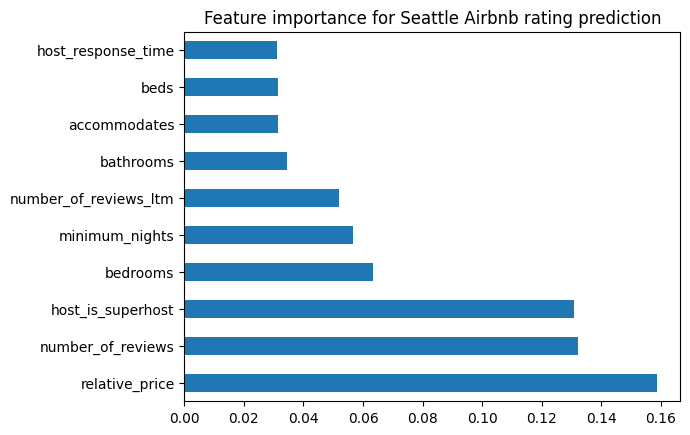

In [30]:
importance.head(10).plot(kind="barh")
plt.title("Feature importance for Seattle Airbnb rating prediction")
plt.show()